## Ce que chat m'a fait en attendant de remplacer par les réponses de Lucie

In [2]:
import numpy as np
import random

def generer_profil_approbations(n, m, niveau_polarisation):
    """
    Génère un profil de votes par approbations avec un certain niveau de polarisation.

    Paramètres:
    - n (int): nombre de votantes
    - m (int): nombre de candidates
    - niveau_polarisation (float): niveau de polarisation (0 = faible, 1 = forte)

    Retourne:
    - profil (list): profil de votes par approbations
    """
    # Génération d'un bulletin aléatoire
    bulletin_aleatoire = np.random.randint(0, 2, size=m)

    # Génération du profil
    profil = []

    # Nombre de votantes dans chaque cluster
    n_cluster_1 = int(n * (1 - niveau_polarisation) / 2)
    n_cluster_2 = n - n_cluster_1

    # Cluster 1: bulletins proches de bulletin_aleatoire
    for _ in range(n_cluster_1):
        bulletin = bulletin_aleatoire.copy()
        # Ajout de bruit pour éviter une polarisation parfaite
        for i in range(m):
            if random.random() < 0.1:  # 10% de chance de changer un vote
                bulletin[i] = 1 - bulletin[i]
        profil.append(bulletin)

    # Cluster 2: bulletins proches de l'opposé de bulletin_aleatoire
    bulletin_oppose = 1 - bulletin_aleatoire
    for _ in range(n_cluster_2):
        bulletin = bulletin_oppose.copy()
        # Ajout de bruit pour éviter une polarisation parfaite
        for i in range(m):
            if random.random() < 0.1:  # 10% de chance de changer un vote
                bulletin[i] = 1 - bulletin[i]
        profil.append(bulletin)

    # Mélange du profil pour éviter un ordre déterministe
    random.shuffle(profil)

    return profil

def generer_profil_ordres_totaux(n, m, niveau_polarisation):
    """
    Génère un profil de votes par ordres totaux avec un certain niveau de polarisation.

    Paramètres:
    - n (int): nombre de votantes
    - m (int): nombre de candidates
    - niveau_polarisation (float): niveau de polarisation (0 = faible, 1 = forte)

    Retourne:
    - profil (list): profil de votes par ordres totaux
    """
    # Génération d'un ordre total aléatoire
    ordre_aleatoire = list(range(m))
    random.shuffle(ordre_aleatoire)

    # Génération du profil
    profil = []

    # Nombre de votantes dans chaque cluster
    n_cluster_1 = int(n * (1 - niveau_polarisation) / 2)
    n_cluster_2 = n - n_cluster_1

    # Cluster 1: ordres proches de ordre_aleatoire
    for _ in range(n_cluster_1):
        ordre = ordre_aleatoire.copy()
        # Ajout de bruit pour éviter une polarisation parfaite
        if random.random() < 0.3:  # 30% de chance de permuter deux éléments
            i, j = random.sample(range(m), 2)
            ordre[i], ordre[j] = ordre[j], ordre[i]
        profil.append(ordre)

    # Cluster 2: ordres proches de l'opposé de ordre_aleatoire
    ordre_oppose = ordre_aleatoire[::-1]
    for _ in range(n_cluster_2):
        ordre = ordre_oppose.copy()
        # Ajout de bruit pour éviter une polarisation parfaite
        if random.random() < 0.3:  # 30% de chance de permuter deux éléments
            i, j = random.sample(range(m), 2)
            ordre[i], ordre[j] = ordre[j], ordre[i]
        profil.append(ordre)

    # Mélange du profil pour éviter un ordre déterministe
    random.shuffle(profil)

    return profil

# Exemple d'utilisation
n = 10  # nombre de votantes
m = 4   # nombre de candidates

# Génération de profils avec différents niveaux de polarisation
profil_approbations_faible = generer_profil_approbations(n, m, niveau_polarisation=0.1)
profil_approbations_fort = generer_profil_approbations(n, m, niveau_polarisation=0.9)

profil_ordres_faible = generer_profil_ordres_totaux(n, m, niveau_polarisation=0.1)
profil_ordres_fort = generer_profil_ordres_totaux(n, m, niveau_polarisation=0.9)

print("Profil d'approbations (faible polarisation) :")
print(profil_approbations_faible)
print("\nProfil d'approbations (forte polarisation) :")
print(profil_approbations_fort)

print("\nProfil d'ordres totaux (faible polarisation) :")
print(profil_ordres_faible)
print("\nProfil d'ordres totaux (forte polarisation) :")
print(profil_ordres_fort)


Profil d'approbations (faible polarisation) :
[array([1, 1, 0, 0]), array([0, 1, 1, 1]), array([1, 0, 1, 1]), array([1, 1, 0, 0]), array([0, 1, 0, 1]), array([0, 0, 1, 1]), array([1, 0, 1, 1]), array([0, 0, 0, 1]), array([1, 1, 0, 1]), array([0, 1, 0, 0])]

Profil d'approbations (forte polarisation) :
[array([1, 0, 0, 1]), array([1, 0, 1, 1]), array([1, 0, 0, 1]), array([1, 0, 0, 1]), array([1, 0, 0, 1]), array([1, 0, 1, 1]), array([1, 0, 0, 1]), array([1, 0, 0, 1]), array([1, 0, 0, 1]), array([1, 0, 0, 1])]

Profil d'ordres totaux (faible polarisation) :
[[3, 1, 0, 2], [3, 1, 0, 2], [2, 0, 1, 3], [3, 1, 0, 2], [2, 0, 1, 3], [3, 1, 0, 2], [3, 0, 1, 2], [3, 1, 0, 2], [2, 1, 0, 3], [2, 0, 1, 3]]

Profil d'ordres totaux (forte polarisation) :
[[1, 2, 3, 0], [2, 0, 3, 1], [0, 2, 1, 3], [0, 2, 3, 1], [0, 2, 3, 1], [0, 2, 3, 1], [0, 2, 3, 1], [0, 2, 3, 1], [0, 2, 3, 1], [0, 2, 1, 3]]


## Question 8 : 

In [3]:
def distance_hamming (a,b): #ici b = a'. a et b sont des listes où il y à un 1 à l'indice i où la votance vk approuve i, 0 sinon. De même pour la liste b qui represente les approbations de vl.
    # à l'etat initial, la distance est de 0. 
    distance = 0
    for i in range (len(a)): # a et b sont de même taille car on a un nombre fini de candidates et a et b détermine pour ces m candidates leur approbations
        if a[i] != b[i] : # si dans la liste a qui représente les apprpbations de vk on a un 1 à la position i et un 0 a cette position dans b
            distance = distance + 1 # alors comme l'indicatrice nous le dit, on somme par des 1 dans notre calcul de distance
        else :  #sinon les deux votantes approuvent toutes les deux i ou ne l'approuvent pas toutes les deux
            distance = distance + 0 # on ajoute 0
    return distance

In [11]:
def distance_spearman(a,b): #ici b = a'. a et b sont des listes où a represente l'ordonnancement de préférences de vk et b celle de vl pour les m candidates. Par exemple, si la candidate 3 est positionné à l'indice 2 chez a et à l'indice 3 chez b, c'est que a préfére i à b.
    distance = 0
    for i in range (len(a)): # a et b sont de même taille car on a un nombre fini de candidates et a et b détermine pour ces m candidates leur préférences
        distance = distance + abs(a[i] - b[i]) 
    return distance

## Question 12

In [9]:
import random

def calcul_vote_approbation(profil):
    consensus = [0]*m
    for i in range (m) :
        somme = 0 
        for votes in profil : 
            somme = somme + votes[i]

        if somme > n/2 : 
            consensus[i] = 1
        if somme < n/2 : 
            consensus[i] = 0  
        else :
            consensus[i] = random.randint(0,1)  
    
    u1 = 0
    for votes in profil :
        u1 += distance_hamming(votes, consensus)
    return u1

print(calcul_vote_approbation(generer_profil_approbations(n,m,0.5)))

11


In [ ]:
from scipy.optimize import linear_sum_assignment

def calcul_vote_totaux(profil):
    rank = [0]*m
    candidates = [0]*m
    poids = np.zeros((m,m))
    for vote in profil :
        for position in range(m):
            for candidate in range(m):
                poids[position][candidate] += distance_spearman(candidates, position)
    row_ind, col_ind = linear_sum_assignment(poids)
    u1 = poids[row_ind, col_ind].sum()

    return u1

print(calcul_vote_totaux(generer_profil_ordres_totaux(n,n,0.5)))

TypeError: object of type 'int' has no len()

## Question 13

In [147]:
import random

def distance_hamming(a, b):
    """Calcule la distance de Hamming entre deux bulletins."""
    return sum(1 for i in range(len(a)) if a[i] != b[i])

def calcul_centroide_consensus(cluster):
    if not cluster:
        return None
    
    cluster = np.array(cluster)
    n, m = cluster.shape
    centroide = np.zeros(m, dtype=int)

    for i in range(m):
        somme = np.sum(cluster[:, i])
        if somme > n / 2:
            centroide[i] = 1
        elif somme < n / 2:
            centroide[i] = 0
        else:
            centroide[i] = np.random.randint(0, 2)

    return centroide

def calcul_u2_approbation(profil, max_iter=100):
    """Estime u_2*(p) pour les votes par approbation avec k-means."""
    n = len(profil)
    if n == 0:
        return 0
    m = len(profil[0])

    # Initialisation aléatoire des centroïdes
    centroide1 = random.choice(profil)
    centroide2 = [1 - x for x in centroide1]

    for _ in range(max_iter):
        # Étape 1 : Affectation des bulletins aux clusters
        cluster1 = []
        cluster2 = []
        for bulletin in profil:
            dist1 = distance_hamming(bulletin, centroide1)
            dist2 = distance_hamming(bulletin, centroide2)
            if dist1 <= dist2:
                cluster1.append(bulletin)
            else:
                cluster2.append(bulletin)

        # Étape 2 : Mise à jour des centroïdes en utilisant la logique de la question 12
        new_centroide1 = calcul_centroide_consensus(cluster1)
        new_centroide2 = calcul_centroide_consensus(cluster2)

        if new_centroide1 is None:
            new_centroide1 = centroide1
        if new_centroide2 is None:
            new_centroide2 = centroide2

        # Vérification de la convergence
        if np.array_equal(new_centroide1, centroide1) and np.array_equal(new_centroide2, centroide2):
            break

        centroide1, centroide2 = new_centroide1, new_centroide2

    # Calcul de u_2*(p)
    u2 = 0
    for bulletin in cluster1:
        u2 += distance_hamming(bulletin, centroide1)
    for bulletin in cluster2:
        u2 += distance_hamming(bulletin, centroide2)

    return u2

# Exemple d'utilisation
n = 10
m = 4
profil_approbation = generer_profil_approbations(n, m, 0.5)
u2_approbation = calcul_u2_approbation(profil_approbation)
print(f"Estimation de u_2*(p) pour les votes par approbation : {u2_approbation}")


Estimation de u_2*(p) pour les votes par approbation : 4


In [148]:
from scipy.optimize import linear_sum_assignment
import numpy as np

def distance_spearman(ordre1, ordre2):
    """Calcule la distance de Spearman entre deux ordres totaux."""
    return sum(abs(ordre1.index(c) - ordre2.index(c)) for c in range(len(ordre1)))

def calcul_centroide_consensus_ordres(cluster):
    """Calcule l'ordre consensus pour un cluster donné en utilisant la logique de la question 12."""
    if not cluster:
        return None
    m = len(cluster[0])
    poids = np.zeros((m, m))

    for ordre in cluster:
        for position in range(m):
            for candidate in range(m):
                poids[position][candidate] += abs(ordre.index(candidate) - position)

    row_ind, col_ind = linear_sum_assignment(poids)
    ordre_consensus = [0] * m
    for pos, cand in zip(row_ind, col_ind):
        ordre_consensus[pos] = cand
    return ordre_consensus

def calcul_u2_ordres_totaux(profil, max_iter=100):
    """Estime u_2*(p) pour les votes par ordres totaux avec k-means."""
    n = len(profil)
    if n == 0:
        return 0

    # Initialisation aléatoire des centroïdes
    centroide1 = random.choice(profil)
    centroide2 = centroide1[::-1]

    for _ in range(max_iter):
        # Étape 1 : Affectation des ordres aux clusters
        cluster1 = []
        cluster2 = []
        for ordre in profil:
            dist1 = distance_spearman(ordre, centroide1)
            dist2 = distance_spearman(ordre, centroide2)
            if dist1 <= dist2:
                cluster1.append(ordre)
            else:
                cluster2.append(ordre)

        # Étape 2 : Mise à jour des centroïdes en utilisant la logique de la question 12
        new_centroide1 = calcul_centroide_consensus_ordres(cluster1)
        new_centroide2 = calcul_centroide_consensus_ordres(cluster2)

        if new_centroide1 is None:
            new_centroide1 = centroide1
        if new_centroide2 is None:
            new_centroide2 = centroide2

        # Vérification de la convergence
        if (new_centroide1 == centroide1) and (new_centroide2 == centroide2):
            break

        centroide1, centroide2 = new_centroide1, new_centroide2
    
    # Calcul de u_2*(p)
    u2 = 0
    for ordre in cluster1:
        u2 += distance_spearman(ordre, centroide1)
    for ordre in cluster2:
        u2 += distance_spearman(ordre, centroide2)

    return u2

# Exemple d'utilisation
profil_ordres = generer_profil_ordres_totaux(n, m, 0.5)
u2_ordres = calcul_u2_ordres_totaux(profil_ordres)
print(f"Estimation de u_2*(p) pour les votes par ordres totaux : {u2_ordres}")


Estimation de u_2*(p) pour les votes par ordres totaux : 0


## Question 14 : 

In [149]:
def phi_hamming(p):
    #Ajout de ces 4 lignes après avoir constaté à la question 15 que sans cela on pouvait avoir des division par 0
    if n == 0 : 
        return 0
    if m == 0 :
        return 0
    
    u1_h = calcul_vote_approbation(p)
    u2_h = calcul_u2_approbation(p)
    numerateur = 2 * (u1_h-u2_h)
    denominateur = n*m
    calcul = numerateur/denominateur
    return calcul
    

In [150]:
def phi_spearman(p):
    #Ajout de ces 4 lignes après avoir constaté à la question 15 que sans cela on pouvait avoir des division par 0
    if n == 0 : 
        return 0
    if m == 0 :
        return 0  
    u1_s = calcul_vote_totaux(p)
    u2_s = calcul_u2_ordres_totaux(p)
    num = 4*(u1_s-u2_s)
    den = n * (m**2)
    res = num/den
    return res

### Test

Ici, on a une polarisation de 0.9 soit proche de 1. On devrait donc obtenir un 𝛟 proche de 1.

In [151]:
p = generer_profil_approbations(20, 5, 0.9)
print(phi_hamming(p))

0.0


Ici, on a une polarisation très faible (de 0.1). On devrait donc obtenir un 𝛟 proche de 0.

In [152]:
p = generer_profil_approbations(20, 5, 0.1)
print(phi_hamming(p))

1.3


## Question 15 : 

### Évolution des mesures 𝜑_dh

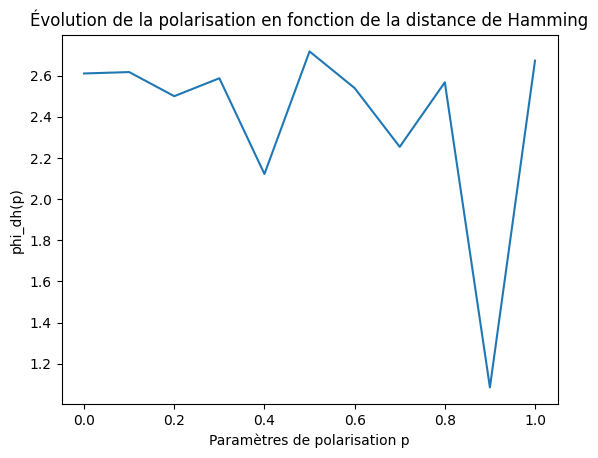

In [153]:
import matplotlib.pyplot as plt
niveau_polarisation = [k/10 for k in range (11)]

phi = [] #on créer une liste pour pouvoir enregistré les différentes valeurs données

for i in niveau_polarisation :
    moyenne = 0
    nb_tests = 20
    for n in range (nb_tests):
        p = generer_profil_approbations(20,5,i)
        moyenne = moyenne + phi_hamming(p)
    phi.append(moyenne/nb_tests)

plt.plot(niveau_polarisation,phi)
plt.xlabel("Paramètres de polarisation p")
plt.ylabel("phi_dh(p)")
plt.title("Évolution de la polarisation en fonction de la distance de Hamming")
plt.show()



### Évolution des mesures 𝜑_ds

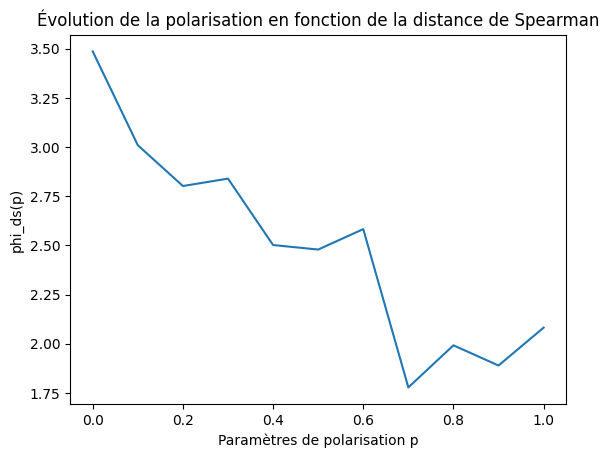

In [154]:
niveau_polarisation = [k/10 for k in range (11)]

phi = [] #on créer une liste pour pouvoir enregistré les différentes valeurs données

for i in niveau_polarisation :
    moyenne = 0
    nb_tests = 20
    for n in range (nb_tests):
        p = generer_profil_ordres_totaux(20,5,i)
        moyenne = moyenne + phi_spearman(p)
    phi.append(moyenne/nb_tests)

plt.plot(niveau_polarisation,phi)
plt.xlabel("Paramètres de polarisation p")
plt.ylabel("phi_ds(p)")
plt.title("Évolution de la polarisation en fonction de la distance de Spearman")
plt.show()
